# Analisis dan Segmentasi Developer serta Prediksi Penggunaan AI Tools

Notebook ini menggunakan dataset Stack Overflow Developer Survey 2025 untuk melakukan segmentasi developer dan memprediksi penggunaan AI Tools.

Target supervised learning adalah `AI_Usage`, yang dibuat dari kolom `AISelect`.

Nilai target:
- `1` = developer menggunakan AI Tools
- `0` = developer tidak menggunakan AI Tools

Pipeline utama:
1. Load dataset Stack Overflow Developer Survey 2025.
2. Cek struktur dataset dan ketersediaan kolom.
3. Buat target `AI_Usage` dari `AISelect`.
4. Pilih fitur yang relevan dan hindari data leakage dari kolom AI.
5. Lakukan preprocessing data.
6. Jalankan segmentasi developer menggunakan K-Means dan Gaussian Mixture Model.
7. Latih model klasifikasi Random Forest, Linear SVM, XGBoost, dan MLP Neural Network.
8. Evaluasi model menggunakan accuracy, precision, recall, F1-score, confusion matrix, dan classification report.
9. Simpan visualisasi, tabel evaluasi, dan ringkasan hasil ke folder `outputs`.

Catatan:
K-Means dan Gaussian Mixture Model digunakan untuk segmentasi developer. Random Forest, Linear SVM, XGBoost, dan MLP Neural Network digunakan untuk prediksi penggunaan AI Tools.

In [9]:
# =========================================================
# 1. SETUP PROJECT, PATH, DAN MODULE
# =========================================================

from pathlib import Path
import sys
import pandas as pd

from IPython.display import Image as Img, display


# =========================================================
# 1.1 PROJECT ROOT
# =========================================================

# Jika notebook dijalankan dari folder "notebooks",
# root project berada satu level di atas folder tersebut.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

print("PROJECT ROOT:", PROJECT_ROOT)
print("SRC DIR:", SRC_DIR)
print("SRC EXISTS:", SRC_DIR.exists())


# =========================================================
# 1.2 MENAMBAHKAN FOLDER SRC KE PYTHON PATH
# =========================================================

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Folder src tidak ditemukan: {SRC_DIR}\n"
        "Pastikan struktur folder project sudah benar."
    )

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# =========================================================
# 1.3 OUTPUT DIRECTORY
# =========================================================

OUTPUT_ROOT = PROJECT_ROOT / "outputs"

FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
REPORTS_DIR = OUTPUT_ROOT / "reports"

for folder in [FIGURES_DIR, TABLES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("OUTPUT ROOT:", OUTPUT_ROOT)


# =========================================================
# 1.4 IMPORT MODULE DATA PREPROCESSING
# =========================================================

from data_preprocessing import (
    CANDIDATE_FEATURES,
    TARGET_SOURCE_COLUMN,
    build_preprocessor,
    find_dataset_path,
    load_survey_data,
    prepare_model_data
)


# =========================================================
# 1.5 HELPER FUNCTION UNTUK CEK KOLOM
# =========================================================

def inspect_candidate_columns(df, candidate_features):
    """
    Mengecek fitur kandidat yang tersedia dan tidak tersedia di dataset.

    Fungsi ini sengaja dibuat di notebook agar tidak bergantung pada src.
    Output-nya digunakan untuk dokumentasi dan validasi fitur.
    """
    rows = []

    for feature in candidate_features:
        is_available = feature in df.columns

        rows.append({
            "feature": feature,
            "available": is_available,
            "status": "Available" if is_available else "Missing"
        })

    result = pd.DataFrame(rows)

    total_features = len(candidate_features)
    total_available = result["available"].sum()
    total_missing = total_features - total_available

    print("Candidate Feature Check")
    print("Total candidate features:", total_features)
    print("Available features:", total_available)
    print("Missing features:", total_missing)

    return result


# =========================================================
# 1.6 IMPORT MODULE EVALUATION
# =========================================================

from evaluate_models import (
    evaluate_classification_models,
    plot_cluster_distribution,
    plot_confusion_matrices,
    plot_gmm_metrics,
    plot_kmeans_metrics,
    plot_model_comparison,
    save_classification_outputs
)


# =========================================================
# 1.7 IMPORT MODULE TRAINING
# =========================================================

from train_models import (
    run_gmm_analysis,
    run_kmeans_analysis,
    summarize_clusters,
    train_classification_models
)


# =========================================================
# 1.8 PANDAS DISPLAY CONFIGURATION
# =========================================================

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("\nSetup selesai. Semua module berhasil di-import.")

PROJECT ROOT: c:\Dokumen\Semester 4\Machine Learning\Machine-AI
SRC DIR: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\src
SRC EXISTS: True
OUTPUT ROOT: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs

Setup selesai. Semua module berhasil di-import.


# 2. Load Dataset Stack Overflow Developer Survey 2025

Bagian ini memuat dataset utama yang digunakan dalam penelitian. Dataset yang digunakan hanya tahun 2025 agar struktur kolom stabil dan pipeline Machine Learning lebih mudah dikontrol.

File dataset yang digunakan adalah `results.csv`.

In [10]:
# =========================================================
# 2. LOAD DATASET STACK OVERFLOW DEVELOPER SURVEY 2025
# =========================================================

# Dataset utama project
DATA_PATH = PROJECT_ROOT / "Survey" / "packages" / "archive" / "2025" / "results.csv"

print("PROJECT ROOT:", PROJECT_ROOT)
print("DATA PATH:", DATA_PATH)
print("DATA EXISTS:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di path:\n{DATA_PATH}\n\n"
        "Pastikan file results.csv berada di folder:\n"
        "Survey/packages/archive/2025/"
    )


# =========================================================
# 2.1 LOAD DATASET
# =========================================================

df = load_survey_data(DATA_PATH)

print("\nDataset berhasil dimuat.")
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]:,}")

display(df.head())

PROJECT ROOT: c:\Dokumen\Semester 4\Machine Learning\Machine-AI
DATA PATH: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\Survey\packages\archive\2025\results.csv
DATA EXISTS: True

Dataset berhasil dimuat.
Jumlah baris: 49,191
Jumlah kolom: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,...,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,...,openAI GPT (chatbot models);openAI Image gener...,NaN,NaN,NaN,NaN,Yes,A few times per week,Between 5 and 10 years,I have never participated in Q&A on Stack Over...,NaN,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 

In [14]:
# =========================================================
# 2.2 INFORMASI DASAR DATASET
# =========================================================

dataset_info = pd.DataFrame({
    "Informasi": [
        "Nama dataset",
        "Tahun dataset",
        "Jumlah baris",
        "Jumlah kolom",
        "Sumber file"
    ],
    "Nilai": [
        "Stack Overflow Developer Survey",
        "2025",
        df.shape[0],
        df.shape[1],
        str(DATA_PATH)
    ]
})

display(dataset_info)

dataset_info.to_csv(TABLES_DIR / "dataset_info_2025.csv", index=False)
print("Dataset info disimpan ke:", TABLES_DIR / "dataset_info_2025.csv")

,Informasi,Nilai
0,Nama dataset,Stack Overflow Developer Survey
1,Tahun dataset,2025
2,Jumlah baris,49191
3,Jumlah kolom,172
4,Sumber file,c:\Dokumen\Semester 4\Machine Learning\Machine...


Dataset info disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\dataset_info_2025.csv


# 3. Pemeriksaan Struktur Kolom Dataset

Bagian ini digunakan untuk memeriksa struktur kolom pada dataset, mengecek ketersediaan fitur kandidat, dan memastikan kolom target `AISelect` tersedia.

Pemeriksaan ini penting karena dataset survei dapat memiliki banyak kolom, termasuk kolom yang tidak boleh digunakan sebagai fitur karena berpotensi menyebabkan data leakage.

In [11]:
# =========================================================
# 3. PEMERIKSAAN STRUKTUR KOLOM DATASET
# =========================================================

# =========================================================
# 3.1 DAFTAR SEMUA KOLOM DATASET
# =========================================================

columns_df = pd.DataFrame({
    "column_name": df.columns
})

columns_output_path = TABLES_DIR / "available_columns_2025.csv"
columns_df.to_csv(columns_output_path, index=False)

print("Jumlah kolom tersedia:", len(df.columns))
print("Daftar kolom disimpan ke:", columns_output_path)

display(columns_df.head(20))

Jumlah kolom tersedia: 172
Daftar kolom disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\available_columns_2025.csv


,column_name
0,ResponseId
1,MainBranch
2,Age
3,EdLevel
4,Employment
5,EmploymentAddl
6,WorkExp
7,LearnCodeChoose
8,LearnCode
9,LearnCodeAI


In [15]:
# =========================================================
# 3.2 CEK KETERSEDIAAN FITUR KANDIDAT
# =========================================================

feature_availability = inspect_candidate_columns(df, CANDIDATE_FEATURES)

feature_availability_output_path = TABLES_DIR / "candidate_feature_availability_2025.csv"
feature_availability.to_csv(feature_availability_output_path, index=False)

print("Hasil pengecekan fitur kandidat disimpan ke:", feature_availability_output_path)

display(feature_availability)

Candidate Feature Check
Total candidate features: 13
Available features: 11
Missing features: 2
Hasil pengecekan fitur kandidat disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\candidate_feature_availability_2025.csv


,feature,available,status
0,Age,True,Available
1,Country,True,Available
2,EdLevel,True,Available
3,DevType,True,Available
4,Employment,True,Available
5,RemoteWork,True,Available
6,YearsCode,True,Available
7,YearsCodePro,False,Missing
8,LanguageHaveWorkedWith,True,Available
9,DatabaseHaveWorkedWith,True,Available


In [16]:
# =========================================================
# 3.3 CEK KOLOM TARGET AISelect
# =========================================================

if TARGET_SOURCE_COLUMN in df.columns:
    print("Kolom target ditemukan:", TARGET_SOURCE_COLUMN)

    target_source_distribution = (
        df[TARGET_SOURCE_COLUMN]
        .value_counts(dropna=False)
        .reset_index()
    )

    target_source_distribution.columns = [TARGET_SOURCE_COLUMN, "count"]

    target_source_distribution_output_path = TABLES_DIR / "aiselect_value_counts_2025.csv"
    target_source_distribution.to_csv(target_source_distribution_output_path, index=False)

    display(target_source_distribution)

    print("Distribusi nilai AISelect disimpan ke:", target_source_distribution_output_path)

else:
    ai_like_columns = [col for col in df.columns if "ai" in col.lower()]

    print(f"Kolom target '{TARGET_SOURCE_COLUMN}' tidak ditemukan.")
    print("Kolom yang mengandung kata 'AI':")

    for col in ai_like_columns:
        print("-", col)

    raise ValueError(
        f"Kolom target '{TARGET_SOURCE_COLUMN}' tidak tersedia. "
        "Sesuaikan TARGET_SOURCE_COLUMN di data_preprocessing.py atau notebook."
    )

Kolom target ditemukan: AISelect


,AISelect,count
0,"Yes, I use AI tools daily",15883
1,NaN,15471
2,"Yes, I use AI tools weekly",5958
3,"No, and I don't plan to",5454
4,"Yes, I use AI tools monthly or infrequently",4628
5,"No, but I plan to soon",1797


Distribusi nilai AISelect disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\aiselect_value_counts_2025.csv


In [17]:
# =========================================================
# 3.4 IDENTIFIKASI KOLOM YANG BERPOTENSI DATA LEAKAGE
# =========================================================

ai_related_columns = [
    col for col in df.columns
    if "ai" in col.lower()
]

ai_related_columns_df = pd.DataFrame({
    "ai_related_column": ai_related_columns
})

ai_related_output_path = TABLES_DIR / "ai_related_columns_2025.csv"
ai_related_columns_df.to_csv(ai_related_output_path, index=False)

print("Jumlah kolom terkait AI:", len(ai_related_columns))
print("Kolom terkait AI disimpan ke:", ai_related_output_path)

display(ai_related_columns_df)

Jumlah kolom terkait AI: 44
Kolom terkait AI disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\ai_related_columns_2025.csv


,ai_related_column
0,MainBranch
1,LearnCodeAI
2,AILearnHow
3,AIThreat
4,AIModelsChoice
5,AIModelsHaveWorkedWith
6,AIModelsWantToWorkWith
7,AIModelsAdmired
8,AIModelsHaveEntry
9,AIModelsWantEntry


# 4. Target Engineering dan Feature Selection

Bagian ini membuat target supervised learning `AI_Usage` dari kolom `AISelect`.

Aturan target:
- `AI_Usage = 1` jika jawaban `AISelect` diawali dengan `Yes`
- `AI_Usage = 0` jika jawaban `AISelect` diawali dengan `No`

Data dengan target kosong dihapus karena tidak dapat digunakan untuk supervised learning.

Pada tahap ini juga dilakukan pemilihan fitur input. Kolom yang berkaitan langsung dengan AI tidak digunakan sebagai fitur agar tidak terjadi data leakage.

In [18]:
# =========================================================
# 4. TARGET ENGINEERING DAN FEATURE SELECTION
# =========================================================

print("=" * 60)
print("4. TARGET ENGINEERING DAN FEATURE SELECTION")
print("=" * 60)


# =========================================================
# 4.1 MEMBUAT TARGET DAN MEMILIH FITUR
# =========================================================

try:
    X, y, metadata = prepare_model_data(df)

except KeyError as error:
    print("Error saat membuat target atau memilih fitur.")
    print(error)

    print("\nLangkah pengecekan:")
    print("1. Cek file outputs/tables/available_columns_2025.csv")
    print("2. Pastikan kolom target tersedia:", TARGET_SOURCE_COLUMN)
    print("3. Pastikan konfigurasi fitur di data_preprocessing.py sesuai dataset")

    raise


# =========================================================
# 4.2 RINGKASAN DATA SETELAH TARGET DIBENTUK
# =========================================================

n_rows_after_target_drop = metadata.get("n_rows_after_target_drop", len(X))
available_features = metadata.get("available_features", list(X.columns))
missing_features = metadata.get("missing_features", [])

model_data_summary = pd.DataFrame({
    "Informasi": [
        "Jumlah data setelah target kosong dihapus",
        "Jumlah fitur digunakan",
        "Jumlah fitur kandidat tidak tersedia",
        "Jumlah kelas target"
    ],
    "Nilai": [
        n_rows_after_target_drop,
        len(available_features),
        len(missing_features),
        y.nunique()
    ]
})

display(model_data_summary)

model_data_summary.to_csv(
    TABLES_DIR / "model_data_summary_2025.csv",
    index=False
)

print("Ringkasan data model disimpan ke:", TABLES_DIR / "model_data_summary_2025.csv")

4. TARGET ENGINEERING DAN FEATURE SELECTION


,Informasi,Nilai
0,Jumlah data setelah target kosong dihapus,33720
1,Jumlah fitur digunakan,11
2,Jumlah fitur kandidat tidak tersedia,2
3,Jumlah kelas target,2


Ringkasan data model disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\model_data_summary_2025.csv


In [19]:
# =========================================================
# 4.3 FITUR YANG DIGUNAKAN DAN TIDAK TERSEDIA
# =========================================================

features_used_df = pd.DataFrame({
    "feature": available_features
})

missing_features_df = pd.DataFrame({
    "missing_feature": missing_features
})

features_used_df.to_csv(
    TABLES_DIR / "features_used_2025.csv",
    index=False
)

missing_features_df.to_csv(
    TABLES_DIR / "missing_features_2025.csv",
    index=False
)

print("Fitur yang digunakan:")
display(features_used_df)

print("Fitur kandidat yang tidak tersedia:")
display(missing_features_df if len(missing_features_df) > 0 else pd.DataFrame({"missing_feature": ["Tidak ada"]}))

Fitur yang digunakan:


,feature
0,Age
1,Country
2,EdLevel
3,DevType
4,Employment
5,RemoteWork
6,YearsCode
7,LanguageHaveWorkedWith
8,DatabaseHaveWorkedWith
9,PlatformHaveWorkedWith


Fitur kandidat yang tidak tersedia:


,missing_feature
0,YearsCodePro
1,ToolsTechHaveWorkedWith


In [20]:
# =========================================================
# 4.4 DISTRIBUSI TARGET AI_USAGE
# =========================================================

target_distribution = (
    y.value_counts()
    .sort_index()
    .rename_axis("AI_Usage")
    .reset_index(name="count")
)

target_distribution["label"] = target_distribution["AI_Usage"].map({
    0: "Tidak menggunakan AI Tools",
    1: "Menggunakan AI Tools"
})

target_distribution["percentage"] = (
    target_distribution["count"] / target_distribution["count"].sum() * 100
).round(2)

target_distribution = target_distribution[
    ["AI_Usage", "label", "count", "percentage"]
]

display(target_distribution)

target_distribution.to_csv(
    TABLES_DIR / "target_distribution_2025.csv",
    index=False
)

print("Distribusi target disimpan ke:", TABLES_DIR / "target_distribution_2025.csv")

,AI_Usage,label,count,percentage
0,0,Tidak menggunakan AI Tools,7251,21.5
1,1,Menggunakan AI Tools,26469,78.5


Distribusi target disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\target_distribution_2025.csv


In [21]:
# =========================================================
# 4.5 VALIDASI DATA LEAKAGE
# =========================================================

ai_columns_in_features = [
    col for col in X.columns
    if "ai" in col.lower()
]

if len(ai_columns_in_features) == 0:
    print("Validasi data leakage: aman.")
    print("Tidak ada kolom terkait AI yang digunakan sebagai fitur input.")
else:
    print("Peringatan: ada kolom terkait AI di fitur input.")
    display(pd.DataFrame({"ai_column_in_features": ai_columns_in_features}))

Validasi data leakage: aman.
Tidak ada kolom terkait AI yang digunakan sebagai fitur input.


In [22]:
# =========================================================
# 4.6 CEK DATA FINAL UNTUK MODEL
# =========================================================

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Missing values di target:", y.isna().sum())

print("\nDistribusi final target:")
print(y.value_counts().sort_index())

print("\nContoh data fitur:")
display(X.head())

Shape X: (33720, 11)
Shape y: (33720,)
Missing values di target: 0

Distribusi final target:
AI_Usage
0     7251
1    26469
Name: count, dtype: int64

Contoh data fitur:


,Age,Country,EdLevel,DevType,Employment,RemoteWork,YearsCode,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith
0,25-34 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Developer, mobile",Employed,Remote,14.0,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN
1,25-34 years old,Netherlands,"Associate degree (A.A., A.S., etc.)","Developer, back-end",Employed,"Hybrid (some in-person, leans heavy to flexibi...",10.0,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot
2,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, front-end","Independent contractor, freelancer, or self-em...",NaN,12.0,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React
3,35-44 years old,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, back-end",Employed,Remote,5.0,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot
4,35-44 years old,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Engineering manager,"Independent contractor, freelancer, or self-em...",NaN,22.0,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery


# 5. Preprocessing Data

Bagian ini membangun pipeline preprocessing untuk menyiapkan data sebelum digunakan oleh model Machine Learning.

Tahapan preprocessing yang digunakan:
1. Missing value numerik diisi dengan median.
2. Missing value kategorikal diisi dengan `Unknown`.
3. Fitur numerik diskalakan menggunakan `StandardScaler`.
4. Fitur kategorikal diubah menjadi representasi numerik menggunakan encoding.
5. Fitur multi-label yang berisi banyak nilai dalam satu kolom diproses agar dapat digunakan oleh model.

Preprocessing dilakukan menggunakan pipeline agar proses transformasi data konsisten untuk supervised learning dan unsupervised learning.

In [27]:
# =========================================================
# FIX BUILD_PREPROCESSOR UNTUK NOTEBOOK
# =========================================================

import numpy as np
import pandas as pd

from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


class SemicolonMultiHotEncoder(BaseEstimator, TransformerMixin):
    """
    Encoder untuk fitur multi-label yang dipisahkan dengan tanda semicolon (;).

    Contoh:
    Python;JavaScript;SQL

    Output:
    Setiap token menjadi fitur biner.
    """

    def __init__(self, separator=";"):
        self.separator = separator

    def fit(self, X, y=None):
        X_df = self._to_dataframe(X)

        self.columns_ = list(X_df.columns)
        vocabulary = set()

        for col in self.columns_:
            values = X_df[col].fillna("").astype(str)

            for value in values:
                tokens = self._split_tokens(value)

                for token in tokens:
                    vocabulary.add(f"{col}={token}")

        self.vocabulary_ = sorted(vocabulary)
        self.token_to_index_ = {
            token: idx for idx, token in enumerate(self.vocabulary_)
        }

        return self

    def transform(self, X):
        X_df = self._to_dataframe(X)

        rows = []
        cols = []
        data = []

        for row_idx, (_, row) in enumerate(X_df.iterrows()):
            for col in self.columns_:
                value = row[col] if col in row.index else ""
                tokens = self._split_tokens(value)

                for token in tokens:
                    feature_name = f"{col}={token}"

                    if feature_name in self.token_to_index_:
                        rows.append(row_idx)
                        cols.append(self.token_to_index_[feature_name])
                        data.append(1)

        return sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(len(X_df), len(self.vocabulary_))
        )

    def get_feature_names_out(self, input_features=None):
        return np.array(
            [f"multi__{feature}" for feature in self.vocabulary_],
            dtype=object
        )

    def _split_tokens(self, value):
        if pd.isna(value):
            return []

        value = str(value)

        if value.strip() == "":
            return []

        tokens = [
            token.strip()
            for token in value.split(self.separator)
            if token.strip()
        ]

        tokens = [
            token for token in tokens
            if token.lower() not in ["nan", "none", "unknown"]
        ]

        return sorted(set(tokens))

    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()

        return pd.DataFrame(X, columns=getattr(self, "columns_", None))


def build_preprocessor(X):
    """
    Membuat preprocessing pipeline untuk dataset Stack Overflow 2025.

    Output:
    1. preprocessor: ColumnTransformer sklearn
    2. feature_groups: ringkasan kelompok fitur
    """

    X = X.copy()

    numeric_features = [
        col for col in X.columns
        if pd.api.types.is_numeric_dtype(X[col])
    ]

    object_features = [
        col for col in X.columns
        if col not in numeric_features
    ]

    known_multilabel_features = [
        "LanguageHaveWorkedWith",
        "DatabaseHaveWorkedWith",
        "PlatformHaveWorkedWith",
        "WebframeHaveWorkedWith",
        "DevEnvsHaveWorkedWith",
        "OpSysProfessional use"
    ]

    detected_multilabel_features = []

    for col in object_features:
        sample_values = X[col].dropna().astype(str).head(1000)

        has_semicolon = sample_values.str.contains(";", regex=False).any()
        is_known_multilabel = col in known_multilabel_features

        if has_semicolon or is_known_multilabel:
            detected_multilabel_features.append(col)

    categorical_features = [
        col for col in object_features
        if col not in detected_multilabel_features
    ]

    transformers = []

    if numeric_features:
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        transformers.append(
            ("numeric", numeric_pipeline, numeric_features)
        )

    if categorical_features:
        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ])

        transformers.append(
            ("categorical", categorical_pipeline, categorical_features)
        )

    if detected_multilabel_features:
        multilabel_pipeline = Pipeline(steps=[
            ("multihot", SemicolonMultiHotEncoder(separator=";"))
        ])

        transformers.append(
            ("multilabel", multilabel_pipeline, detected_multilabel_features)
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True
    )

    feature_groups = {
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "multilabel_features": detected_multilabel_features
    }

    return preprocessor, feature_groups


print("build_preprocessor berhasil di-override di notebook.")

build_preprocessor berhasil di-override di notebook.


In [28]:
# =========================================================
# 5. PREPROCESSING DATA
# =========================================================

print("=" * 60)
print("5. PREPROCESSING DATA")
print("=" * 60)


# =========================================================
# 5.1 MEMBANGUN PREPROCESSOR
# =========================================================

preprocessor, feature_groups = build_preprocessor(X)

print("Preprocessor berhasil dibuat.")
print("Jumlah feature group:", len(feature_groups))

5. PREPROCESSING DATA
Preprocessor berhasil dibuat.
Jumlah feature group: 3


In [29]:
# =========================================================
# 5.2 RINGKASAN FEATURE GROUP
# =========================================================

feature_groups_df = pd.DataFrame({
    "feature_group": list(feature_groups.keys()),
    "n_columns": [
        len(cols) if isinstance(cols, list) else 1
        for cols in feature_groups.values()
    ],
    "columns": [
        ", ".join(cols) if isinstance(cols, list) else str(cols)
        for cols in feature_groups.values()
    ]
})

display(feature_groups_df)

feature_groups_df.to_csv(
    TABLES_DIR / "feature_groups_2025.csv",
    index=False
)

print("Ringkasan feature group disimpan ke:", TABLES_DIR / "feature_groups_2025.csv")

,feature_group,n_columns,columns
0,numeric_features,1,YearsCode
1,categorical_features,6,"Age, Country, EdLevel, DevType, Employment, Re..."
2,multilabel_features,4,"LanguageHaveWorkedWith, DatabaseHaveWorkedWith..."


Ringkasan feature group disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\feature_groups_2025.csv


In [30]:
# =========================================================
# 5.3 DETAIL FEATURE GROUP
# =========================================================

for group_name, columns in feature_groups.items():
    print("=" * 60)
    print(group_name.upper())
    print("=" * 60)

    if isinstance(columns, list):
        for col in columns:
            print("-", col)
    else:
        print("-", columns)

    print()

NUMERIC_FEATURES
- YearsCode

CATEGORICAL_FEATURES
- Age
- Country
- EdLevel
- DevType
- Employment
- RemoteWork

MULTILABEL_FEATURES
- LanguageHaveWorkedWith
- DatabaseHaveWorkedWith
- PlatformHaveWorkedWith
- WebframeHaveWorkedWith



In [31]:
# =========================================================
# 5.4 VALIDASI OUTPUT PREPROCESSING
# =========================================================

preprocessor_check = clone(preprocessor)
X_preprocessed_check = preprocessor_check.fit_transform(X)

print("Preprocessing berhasil dijalankan.")
print("Shape sebelum preprocessing:", X.shape)
print("Shape setelah preprocessing:", X_preprocessed_check.shape)
print("Tipe data setelah preprocessing:", type(X_preprocessed_check))

Preprocessing berhasil dijalankan.
Shape sebelum preprocessing: (33720, 11)
Shape setelah preprocessing: (33720, 379)
Tipe data setelah preprocessing: <class 'scipy.sparse._csr.csr_matrix'>


# 6. Unsupervised Learning: Segmentasi Developer

Bagian ini digunakan untuk melakukan segmentasi developer berdasarkan karakteristik, pengalaman, pola kerja, dan teknologi yang digunakan.

Model unsupervised learning yang digunakan:
1. K-Means Clustering
2. Gaussian Mixture Model

K-Means digunakan sebagai baseline clustering. Model ini membagi data ke dalam beberapa cluster berdasarkan kedekatan jarak antar data.

Evaluasi K-Means dilakukan menggunakan:
1. Elbow Method untuk melihat pola penurunan inertia.
2. Silhouette Score untuk mengukur kualitas pemisahan cluster.

Karena hasil preprocessing menghasilkan fitur berdimensi tinggi, terutama dari one-hot encoding dan multi-label encoding, data direduksi terlebih dahulu menggunakan TruncatedSVD sebelum clustering.

In [37]:
# =========================================================
# FIX RUN_KMEANS_ANALYSIS UNTUK NOTEBOOK
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score


def run_kmeans_analysis(X, preprocessor, k_values=range(2, 11), n_components=50, random_state=42):
    """
    Menjalankan K-Means clustering untuk data hasil preprocessing.

    Tahapan:
    1. Fit-transform preprocessing.
    2. Reduksi dimensi menggunakan TruncatedSVD.
    3. Evaluasi beberapa nilai k dengan inertia dan silhouette score.
    4. Pilih k terbaik berdasarkan silhouette score.
    5. Fit final K-Means menggunakan k terbaik.
    """

    print("Menjalankan preprocessing untuk K-Means...")
    preprocessor_model = clone(preprocessor)
    X_processed = preprocessor_model.fit_transform(X)

    print("Shape setelah preprocessing:", X_processed.shape)

    max_components = min(n_components, X_processed.shape[1] - 1)

    if max_components < 2:
        raise ValueError("Jumlah fitur setelah preprocessing terlalu sedikit untuk TruncatedSVD.")

    print(f"Menjalankan TruncatedSVD dengan {max_components} komponen...")
    svd = TruncatedSVD(
        n_components=max_components,
        random_state=random_state
    )

    X_reduced = svd.fit_transform(X_processed)

    print("Shape setelah TruncatedSVD:", X_reduced.shape)

    metrics = []

    print("\nEvaluasi beberapa nilai k:")

    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        labels = kmeans.fit_predict(X_reduced)

        sil_score = silhouette_score(
            X_reduced,
            labels,
            sample_size=min(5000, X_reduced.shape[0]),
            random_state=random_state
        )

        metrics.append({
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_score": sil_score
        })

        print(f"k={k} | inertia={kmeans.inertia_:.2f} | silhouette={sil_score:.4f}")

    metrics_df = pd.DataFrame(metrics)

    best_k = int(
        metrics_df.sort_values(
            by="silhouette_score",
            ascending=False
        )["k"].iloc[0]
    )

    print("\nBest k berdasarkan Silhouette Score:", best_k)

    final_kmeans = KMeans(
        n_clusters=best_k,
        random_state=random_state,
        n_init=10
    )

    final_labels = final_kmeans.fit_predict(X_reduced)

    return {
        "metrics": metrics_df,
        "best_k": best_k,
        "labels": final_labels,
        "model": final_kmeans,
        "svd": svd,
        "preprocessor": preprocessor_model,
        "X_reduced": X_reduced
    }


print("run_kmeans_analysis berhasil di-override di notebook.")

run_kmeans_analysis berhasil di-override di notebook.


## 6.1 K-Means Clustering

In [38]:
# =========================================================
# 6.1 K-MEANS CLUSTERING
# =========================================================

print("=" * 60)
print("6.1 K-MEANS CLUSTERING")
print("=" * 60)


# =========================================================
# 6.1.1 TRAINING DAN EVALUASI K-MEANS
# =========================================================

kmeans_result = run_kmeans_analysis(
    X,
    preprocessor,
    k_values=range(2, 11)
)


# =========================================================
# 6.1.2 AMBIL HASIL K-MEANS
# =========================================================

kmeans_metrics = kmeans_result["metrics"]
best_k = kmeans_result["best_k"]
kmeans_labels = kmeans_result["labels"]


# =========================================================
# 6.1.3 SIMPAN METRICS K-MEANS
# =========================================================

kmeans_metrics_output_path = TABLES_DIR / "kmeans_metrics_2025.csv"

kmeans_metrics.to_csv(
    kmeans_metrics_output_path,
    index=False
)

print("Metrics K-Means disimpan ke:", kmeans_metrics_output_path)


# =========================================================
# 6.1.4 TAMPILKAN HASIL K-MEANS
# =========================================================

print("\nHasil K-Means")
print("Jumlah cluster terbaik berdasarkan evaluasi:", best_k)

display(kmeans_metrics)

6.1 K-MEANS CLUSTERING
Menjalankan preprocessing untuk K-Means...
Shape setelah preprocessing: (33720, 379)
Menjalankan TruncatedSVD dengan 50 komponen...
Shape setelah TruncatedSVD: (33720, 50)

Evaluasi beberapa nilai k:
k=2 | inertia=360550.73 | silhouette=0.1086
k=3 | inertia=338998.70 | silhouette=0.0779
k=4 | inertia=327877.82 | silhouette=0.0792
k=5 | inertia=319059.32 | silhouette=0.0593
k=6 | inertia=310949.07 | silhouette=0.0596
k=7 | inertia=304130.12 | silhouette=0.0586
k=8 | inertia=299171.99 | silhouette=0.0532
k=9 | inertia=295172.77 | silhouette=0.0512
k=10 | inertia=291901.18 | silhouette=0.0496

Best k berdasarkan Silhouette Score: 2
Metrics K-Means disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\kmeans_metrics_2025.csv

Hasil K-Means
Jumlah cluster terbaik berdasarkan evaluasi: 2


,k,inertia,silhouette_score
0,2,360550.725916,0.108568
1,3,338998.704173,0.077929
2,4,327877.816322,0.079203
3,5,319059.323321,0.059334
4,6,310949.072459,0.059623
5,7,304130.123760,0.058574
6,8,299171.989886,0.053196
7,9,295172.769754,0.051197
8,10,291901.181344,0.049576


In [39]:
# =========================================================
# 6.2 DISTRIBUSI CLUSTER K-MEANS
# =========================================================

kmeans_cluster_distribution = (
    pd.Series(kmeans_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

kmeans_cluster_distribution["Persentase"] = (
    kmeans_cluster_distribution["Jumlah Data"]
    / kmeans_cluster_distribution["Jumlah Data"].sum()
    * 100
).round(2)

display(kmeans_cluster_distribution)

kmeans_cluster_distribution_output_path = TABLES_DIR / "kmeans_cluster_distribution_2025.csv"

kmeans_cluster_distribution.to_csv(
    kmeans_cluster_distribution_output_path,
    index=False
)

print("Distribusi cluster K-Means disimpan ke:", kmeans_cluster_distribution_output_path)

,Cluster,Jumlah Data,Persentase
0,0,18818,55.81
1,1,14902,44.19


Distribusi cluster K-Means disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\kmeans_cluster_distribution_2025.csv


Path visualisasi K-Means: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\kmeans_elbow_silhouette.png
File tersedia: True


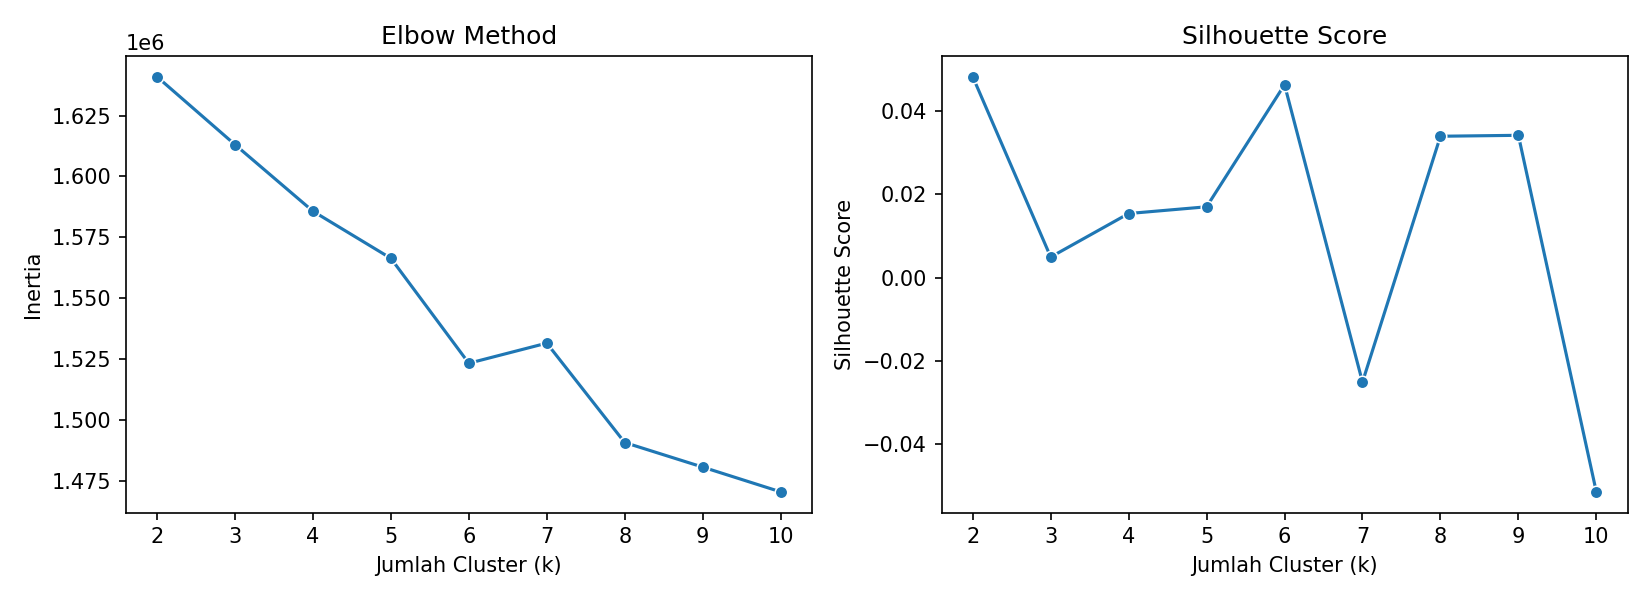

In [41]:
# =========================================================
# 6.3 VISUALISASI EVALUASI K-MEANS
# =========================================================

# Fungsi plot_kmeans_metrics dari evaluate_models.py
# membaca kolom bernama "silhouette".
# Karena metrics kita memakai nama "silhouette_score",
# maka dibuat copy khusus untuk visualisasi.

kmeans_metrics_plot = kmeans_metrics.copy()

if "silhouette" not in kmeans_metrics_plot.columns:
    kmeans_metrics_plot["silhouette"] = kmeans_metrics_plot["silhouette_score"]

plot_kmeans_metrics(kmeans_metrics_plot, OUTPUT_ROOT)

kmeans_plot_path = FIGURES_DIR / "kmeans_elbow_silhouette.png"

print("Path visualisasi K-Means:", kmeans_plot_path)
print("File tersedia:", kmeans_plot_path.exists())

if kmeans_plot_path.exists():
    display(Img(filename=str(kmeans_plot_path)))
else:
    print("Visualisasi K-Means belum ditemukan. Periksa fungsi plot_kmeans_metrics.")

In [42]:
# =========================================================
# 6.4 INTERPRETASI AWAL K-MEANS
# =========================================================

best_k_row = kmeans_metrics[kmeans_metrics["k"] == best_k]

if not best_k_row.empty:
    best_silhouette = best_k_row["silhouette_score"].iloc[0]

    print("Interpretasi awal K-Means")
    print(f"Jumlah cluster terbaik adalah {best_k}.")
    print(f"Silhouette Score pada k terbaik adalah {best_silhouette:.4f}.")

    if best_silhouette < 0.25:
        print(
            "Nilai Silhouette Score tergolong rendah. "
            "Hal ini menunjukkan bahwa pemisahan antar cluster tidak terlalu kuat. "
            "Kondisi ini wajar pada data survei developer karena banyak fitur bersifat kategorikal dan multi-label."
        )
    elif best_silhouette < 0.50:
        print(
            "Nilai Silhouette Score menunjukkan pemisahan cluster sedang. "
            "Cluster dapat digunakan untuk analisis segmentasi awal, tetapi interpretasi perlu dilakukan dengan hati-hati."
        )
    else:
        print(
            "Nilai Silhouette Score menunjukkan pemisahan cluster yang cukup baik. "
            "Cluster dapat digunakan sebagai dasar interpretasi segmentasi developer."
        )
else:
    print("Baris best_k tidak ditemukan pada kmeans_metrics.")

Interpretasi awal K-Means
Jumlah cluster terbaik adalah 2.
Silhouette Score pada k terbaik adalah 0.1086.
Nilai Silhouette Score tergolong rendah. Hal ini menunjukkan bahwa pemisahan antar cluster tidak terlalu kuat. Kondisi ini wajar pada data survei developer karena banyak fitur bersifat kategorikal dan multi-label.


## 6.5 K-Means Cluster Summary

Bagian ini membuat ringkasan hasil segmentasi K-Means. Ringkasan cluster digunakan untuk melihat jumlah data pada setiap cluster dan karakteristik dominan dari developer di masing-masing cluster.

Ringkasan ini membantu menjelaskan hasil segmentasi secara lebih mudah pada laporan BAB IV.

In [56]:
# =========================================================
# 6.5 K-MEANS CLUSTER SUMMARY
# =========================================================

print("=" * 60)
print("6.5 K-MEANS CLUSTER SUMMARY")
print("=" * 60)


# =========================================================
# 6.5.1 HELPER FUNCTION UNTUK RINGKASAN CLUSTER
# =========================================================

print("=" * 60)
print("6.5.1 HELPER FUNCTION UNTUK RINGKASAN CLUSTER")
print("=" * 60)


def get_top_value(series):
    """
    Mengambil nilai paling dominan dari sebuah kolom kategorikal.
    """
    series = series.dropna().astype(str)

    if series.empty:
        return "Tidak tersedia"

    value_counts = series.value_counts()

    return value_counts.index[0]


def get_top_tokens(series, separator=";", top_n=5):
    """
    Mengambil token paling dominan dari kolom multi-label.
    Contoh nilai:
    Python;JavaScript;SQL
    """
    tokens = []

    for value in series.dropna().astype(str):
        for token in value.split(separator):
            token = token.strip()

            if token and token.lower() not in ["nan", "none", "unknown"]:
                tokens.append(token)

    if len(tokens) == 0:
        return "Tidak tersedia"

    token_counts = pd.Series(tokens).value_counts().head(top_n)

    return ", ".join(token_counts.index.tolist())


def create_cluster_summary(X, labels):
    """
    Membuat ringkasan karakteristik setiap cluster.
    """
    cluster_df = X.copy()
    cluster_df["Cluster"] = labels

    summary_rows = []

    numeric_cols = [
        col for col in ["YearsCode", "WorkExp"]
        if col in cluster_df.columns
    ]

    categorical_cols = [
        col for col in [
            "Age",
            "Country",
            "EdLevel",
            "DevType",
            "Employment",
            "RemoteWork",
            "Industry",
            "OrgSize"
        ]
        if col in cluster_df.columns
    ]

    multilabel_cols = [
        col for col in [
            "LanguageHaveWorkedWith",
            "DatabaseHaveWorkedWith",
            "PlatformHaveWorkedWith",
            "WebframeHaveWorkedWith",
            "DevEnvsHaveWorkedWith",
            "OpSysProfessional use"
        ]
        if col in cluster_df.columns
    ]

    total_data = len(cluster_df)

    for cluster_id in sorted(cluster_df["Cluster"].unique()):
        cluster_data = cluster_df[cluster_df["Cluster"] == cluster_id]

        row = {
            "Cluster": cluster_id,
            "Jumlah_Data": len(cluster_data),
            "Persentase": round(len(cluster_data) / total_data * 100, 2)
        }

        for col in numeric_cols:
            row[f"Rata_Rata_{col}"] = round(cluster_data[col].mean(), 2)

        for col in categorical_cols:
            row[f"Dominan_{col}"] = get_top_value(cluster_data[col])

        for col in multilabel_cols:
            row[f"Top_{col}"] = get_top_tokens(cluster_data[col])

        summary_rows.append(row)

    return pd.DataFrame(summary_rows)


helper_functions_df = pd.DataFrame({
    "Function": [
        "get_top_value",
        "get_top_tokens",
        "create_cluster_summary"
    ],
    "Kegunaan": [
        "Mengambil nilai kategorikal yang paling dominan dalam cluster",
        "Mengambil token multi-label yang paling sering muncul dalam cluster",
        "Membuat tabel ringkasan karakteristik setiap cluster"
    ]
})

display(helper_functions_df)

print("Helper function berhasil dibuat dan siap digunakan.")

6.5 K-MEANS CLUSTER SUMMARY
6.5.1 HELPER FUNCTION UNTUK RINGKASAN CLUSTER


,Function,Kegunaan
0,get_top_value,Mengambil nilai kategorikal yang paling domina...
1,get_top_tokens,Mengambil token multi-label yang paling sering...
2,create_cluster_summary,Membuat tabel ringkasan karakteristik setiap c...


Helper function berhasil dibuat dan siap digunakan.


In [57]:
# =========================================================
# 6.5.2 GENERATE K-MEANS CLUSTER SUMMARY
# =========================================================

kmeans_cluster_summary = create_cluster_summary(X, kmeans_labels)

display(kmeans_cluster_summary)

kmeans_cluster_summary_output_path = TABLES_DIR / "kmeans_cluster_summary_2025.csv"

kmeans_cluster_summary.to_csv(
    kmeans_cluster_summary_output_path,
    index=False
)

print("K-Means cluster summary disimpan ke:", kmeans_cluster_summary_output_path)

,Cluster,Jumlah_Data,Persentase,Rata_Rata_YearsCode,Dominan_Age,Dominan_Country,Dominan_EdLevel,Dominan_DevType,Dominan_Employment,Dominan_RemoteWork,Top_LanguageHaveWorkedWith,Top_DatabaseHaveWorkedWith,Top_PlatformHaveWorkedWith,Top_WebframeHaveWorkedWith
0,0,18818,55.81,17.79,25-34 years old,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Employed,Remote,"Python, JavaScript, SQL, HTML/CSS, Bash/Shell ...","PostgreSQL, Microsoft SQL Server, MySQL, SQLit...","Docker, Amazon Web Services (AWS), Pip, Micros...","Node.js, React, ASP.NET Core, jQuery, ASP.NET"
1,1,14902,44.19,16.46,25-34 years old,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Employed,Remote,"JavaScript, HTML/CSS, SQL, TypeScript, Python","PostgreSQL, MySQL, SQLite, Redis, MongoDB","Docker, npm, Amazon Web Services (AWS), Pip, Vite","Node.js, React, Next.js, Express, jQuery"


K-Means cluster summary disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\kmeans_cluster_summary_2025.csv


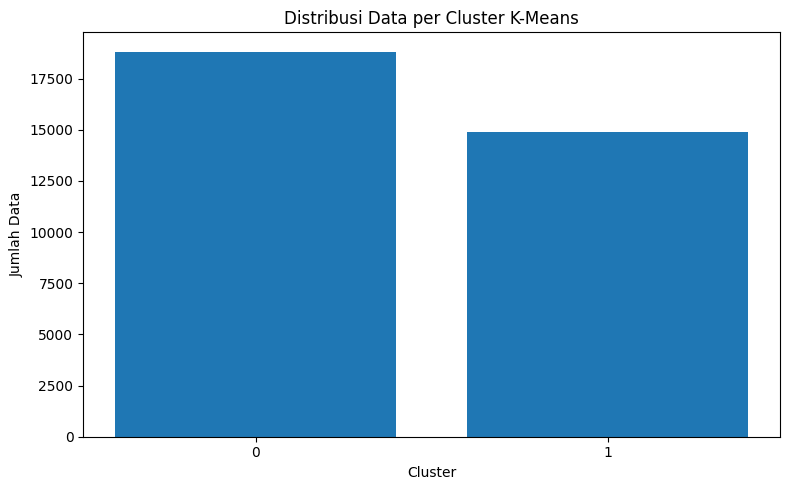

Visualisasi distribusi cluster K-Means disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\kmeans_cluster_distribution_2025.png


In [59]:
# =========================================================
# 6.5.3 VISUALISASI DISTRIBUSI CLUSTER K-MEANS
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    kmeans_cluster_distribution["Cluster"].astype(str),
    kmeans_cluster_distribution["Jumlah Data"]
)

plt.title("Distribusi Data per Cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.tight_layout()

kmeans_cluster_distribution_plot_path = FIGURES_DIR / "kmeans_cluster_distribution_2025.png"

plt.savefig(kmeans_cluster_distribution_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi distribusi cluster K-Means disimpan ke:", kmeans_cluster_distribution_plot_path)

In [61]:
# =========================================================
# 6.5.4 INTERPRETASI RINGKAS K-MEANS
# =========================================================

print("Interpretasi ringkas K-Means:")

for _, row in kmeans_cluster_summary.iterrows():
    cluster_id = row["Cluster"]
    jumlah_data = row["Jumlah_Data"]
    persentase = row["Persentase"]

    print(f"\nCluster {cluster_id}")
    print(f"Jumlah data: {jumlah_data:,} responden ({persentase}%)")

    if "Dominan_DevType" in kmeans_cluster_summary.columns:
        print("DevType dominan:", row["Dominan_DevType"])

    if "Dominan_RemoteWork" in kmeans_cluster_summary.columns:
        print("Pola kerja dominan:", row["Dominan_RemoteWork"])

    if "Top_LanguageHaveWorkedWith" in kmeans_cluster_summary.columns:
        print("Bahasa pemrograman dominan:", row["Top_LanguageHaveWorkedWith"])

Interpretasi ringkas K-Means:

Cluster 0
Jumlah data: 18,818 responden (55.81%)
DevType dominan: Developer, full-stack
Pola kerja dominan: Remote
Bahasa pemrograman dominan: Python, JavaScript, SQL, HTML/CSS, Bash/Shell (all shells)

Cluster 1
Jumlah data: 14,902 responden (44.19%)
DevType dominan: Developer, full-stack
Pola kerja dominan: Remote
Bahasa pemrograman dominan: JavaScript, HTML/CSS, SQL, TypeScript, Python


## 6.5.5 Catatan Interpretasi K-Means

Bagian ini menyusun catatan interpretasi hasil segmentasi K-Means untuk mendukung penulisan BAB IV.

Interpretasi cluster dilakukan berdasarkan:
1. Jumlah data pada setiap cluster.
2. Persentase data pada setiap cluster.
3. Karakteristik dominan seperti negara, tingkat pendidikan, tipe developer, pola kerja, dan teknologi yang digunakan.
4. Rata-rata pengalaman coding melalui `YearsCode`.

Catatan:
Dataset 2025 yang digunakan tidak memiliki kolom `YearsCodePro`. Oleh karena itu, interpretasi pengalaman profesional menggunakan fitur `WorkExp` jika tersedia.

In [62]:
# =========================================================
# 6.5.5 CATATAN INTERPRETASI K-MEANS
# =========================================================

print("=" * 60)
print("6.5.5 CATATAN INTERPRETASI K-MEANS")
print("=" * 60)

interpretation_lines = []

interpretation_lines.append("# Catatan Interpretasi K-Means")
interpretation_lines.append("")
interpretation_lines.append("K-Means digunakan untuk melakukan segmentasi developer berdasarkan fitur profil, pengalaman, pola kerja, dan teknologi yang digunakan.")
interpretation_lines.append("")
interpretation_lines.append(f"Jumlah cluster terbaik berdasarkan evaluasi adalah {best_k}.")
interpretation_lines.append("")

for _, row in kmeans_cluster_summary.iterrows():
    cluster_id = row["Cluster"]
    jumlah_data = row["Jumlah_Data"]
    persentase = row["Persentase"]

    interpretation_lines.append(f"## Cluster {cluster_id}")
    interpretation_lines.append(f"- Jumlah data: {jumlah_data:,} responden")
    interpretation_lines.append(f"- Persentase: {persentase}%")

    if "Rata_Rata_YearsCode" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Rata-rata YearsCode: {row['Rata_Rata_YearsCode']} tahun")

    if "Rata_Rata_WorkExp" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Rata-rata WorkExp: {row['Rata_Rata_WorkExp']} tahun")

    if "Dominan_Age" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Kelompok usia dominan: {row['Dominan_Age']}")

    if "Dominan_Country" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Negara dominan: {row['Dominan_Country']}")

    if "Dominan_EdLevel" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Pendidikan dominan: {row['Dominan_EdLevel']}")

    if "Dominan_DevType" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Tipe developer dominan: {row['Dominan_DevType']}")

    if "Dominan_RemoteWork" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Pola kerja dominan: {row['Dominan_RemoteWork']}")

    if "Top_LanguageHaveWorkedWith" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Bahasa pemrograman dominan: {row['Top_LanguageHaveWorkedWith']}")

    if "Top_DatabaseHaveWorkedWith" in kmeans_cluster_summary.columns:
        interpretation_lines.append(f"- Database dominan: {row['Top_DatabaseHaveWorkedWith']}")

    interpretation_lines.append("")

interpretation_lines.append("## Kesimpulan Awal")
interpretation_lines.append(
    "Hasil K-Means menunjukkan bahwa segmentasi developer dapat dibedakan berdasarkan kombinasi karakteristik demografis, pengalaman coding, pola kerja, dan teknologi yang digunakan. "
    "Namun, nilai Silhouette Score yang rendah menunjukkan bahwa pemisahan antar cluster tidak terlalu kuat. "
    "Hal ini wajar pada dataset survei developer karena data didominasi oleh fitur kategorikal dan multi-label."
)

interpretation_text = "\n".join(interpretation_lines)

print(interpretation_text)

kmeans_interpretation_output_path = REPORTS_DIR / "kmeans_interpretation_2025.md"

with open(kmeans_interpretation_output_path, "w", encoding="utf-8") as file:
    file.write(interpretation_text)

print("\nCatatan interpretasi K-Means disimpan ke:", kmeans_interpretation_output_path)

6.5.5 CATATAN INTERPRETASI K-MEANS
# Catatan Interpretasi K-Means

K-Means digunakan untuk melakukan segmentasi developer berdasarkan fitur profil, pengalaman, pola kerja, dan teknologi yang digunakan.

Jumlah cluster terbaik berdasarkan evaluasi adalah 2.

## Cluster 0
- Jumlah data: 18,818 responden
- Persentase: 55.81%
- Rata-rata YearsCode: 17.79 tahun
- Kelompok usia dominan: 25-34 years old
- Negara dominan: United States of America
- Pendidikan dominan: Bachelor’s degree (B.A., B.S., B.Eng., etc.)
- Tipe developer dominan: Developer, full-stack
- Pola kerja dominan: Remote
- Bahasa pemrograman dominan: Python, JavaScript, SQL, HTML/CSS, Bash/Shell (all shells)
- Database dominan: PostgreSQL, Microsoft SQL Server, MySQL, SQLite, MariaDB

## Cluster 1
- Jumlah data: 14,902 responden
- Persentase: 44.19%
- Rata-rata YearsCode: 16.46 tahun
- Kelompok usia dominan: 25-34 years old
- Negara dominan: United States of America
- Pendidikan dominan: Bachelor’s degree (B.A., B.S., B.Eng., 

## 6.6 Gaussian Mixture Model Clustering

Gaussian Mixture Model digunakan sebagai model clustering modern berbasis probabilistik.

Berbeda dengan K-Means yang menetapkan satu data ke satu cluster secara langsung, GMM menghitung probabilitas setiap data untuk masuk ke masing-masing cluster.

Evaluasi GMM menggunakan:
1. BIC untuk menilai kompleksitas model.
2. AIC untuk menilai kualitas model dengan penalti kompleksitas.
3. Silhouette Score untuk menilai pemisahan cluster.

In [63]:
# =========================================================
# FIX RUN_GMM_ANALYSIS UNTUK NOTEBOOK
# =========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


def run_gmm_analysis(
    X,
    preprocessor,
    k_values=range(2, 9),
    n_components=30,
    sample_size=10000,
    random_state=42
):
    """
    Menjalankan Gaussian Mixture Model untuk clustering developer.

    Tahapan:
    1. Fit-transform preprocessing.
    2. Reduksi dimensi menggunakan TruncatedSVD.
    3. Sampling data agar GMM lebih stabil dan ringan.
    4. Evaluasi beberapa jumlah cluster dengan BIC, AIC, dan Silhouette Score.
    5. Pilih jumlah cluster terbaik berdasarkan Silhouette Score.
    6. Fit final GMM dan prediksi cluster untuk seluruh data.
    """

    print("Menjalankan preprocessing untuk GMM...")
    preprocessor_model = clone(preprocessor)
    X_processed = preprocessor_model.fit_transform(X)

    print("Shape setelah preprocessing:", X_processed.shape)

    max_components = min(n_components, X_processed.shape[1] - 1)

    if max_components < 2:
        raise ValueError("Jumlah fitur setelah preprocessing terlalu sedikit untuk TruncatedSVD.")

    print(f"Menjalankan TruncatedSVD dengan {max_components} komponen...")
    svd = TruncatedSVD(
        n_components=max_components,
        random_state=random_state
    )

    X_reduced = svd.fit_transform(X_processed)

    print("Shape setelah TruncatedSVD:", X_reduced.shape)

    rng = np.random.default_rng(random_state)

    if X_reduced.shape[0] > sample_size:
        sample_indices = rng.choice(
            X_reduced.shape[0],
            size=sample_size,
            replace=False
        )
        X_sample = X_reduced[sample_indices]
    else:
        sample_indices = np.arange(X_reduced.shape[0])
        X_sample = X_reduced

    print("Jumlah data sample untuk evaluasi GMM:", X_sample.shape[0])

    metrics = []

    print("\nEvaluasi beberapa jumlah cluster:")

    for k in k_values:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=3,
            random_state=random_state
        )

        gmm.fit(X_sample)

        sample_labels = gmm.predict(X_sample)

        if len(np.unique(sample_labels)) > 1:
            sil_score = silhouette_score(
                X_sample,
                sample_labels,
                sample_size=min(5000, X_sample.shape[0]),
                random_state=random_state
            )
        else:
            sil_score = np.nan

        bic = gmm.bic(X_sample)
        aic = gmm.aic(X_sample)

        metrics.append({
            "k": k,
            "n_clusters": k,
            "bic": bic,
            "aic": aic,
            "silhouette_score": sil_score,
            "silhouette": sil_score
        })

        print(
            f"k={k} | BIC={bic:.2f} | AIC={aic:.2f} | "
            f"silhouette={sil_score:.4f}"
        )

    metrics_df = pd.DataFrame(metrics)

    best_k = int(
        metrics_df
        .dropna(subset=["silhouette_score"])
        .sort_values(by="silhouette_score", ascending=False)
        ["k"]
        .iloc[0]
    )

    print("\nBest k GMM berdasarkan Silhouette Score:", best_k)

    final_gmm = GaussianMixture(
        n_components=best_k,
        covariance_type="full",
        n_init=3,
        random_state=random_state
    )

    final_gmm.fit(X_sample)

    final_labels = final_gmm.predict(X_reduced)
    final_probabilities = final_gmm.predict_proba(X_reduced)

    return {
        "metrics": metrics_df,
        "best_k": best_k,
        "labels": final_labels,
        "probabilities": final_probabilities,
        "model": final_gmm,
        "svd": svd,
        "preprocessor": preprocessor_model,
        "X_reduced": X_reduced,
        "sample_indices": sample_indices
    }


print("run_gmm_analysis berhasil di-override di notebook.")

run_gmm_analysis berhasil di-override di notebook.


In [64]:
# =========================================================
# 6.6 GMM CLUSTERING
# =========================================================

print("=" * 60)
print("6.6 GAUSSIAN MIXTURE MODEL CLUSTERING")
print("=" * 60)


# =========================================================
# 6.6.1 TRAINING DAN EVALUASI GMM
# =========================================================

gmm_result = run_gmm_analysis(
    X,
    preprocessor,
    k_values=range(2, 9)
)


# =========================================================
# 6.6.2 AMBIL HASIL GMM
# =========================================================

gmm_metrics = gmm_result["metrics"]
gmm_best_k = gmm_result["best_k"]
gmm_labels = gmm_result["labels"]
gmm_probabilities = gmm_result["probabilities"]


# =========================================================
# 6.6.3 SIMPAN METRICS GMM
# =========================================================

gmm_metrics_output_path = TABLES_DIR / "gmm_metrics_2025.csv"

gmm_metrics.to_csv(
    gmm_metrics_output_path,
    index=False
)

print("Metrics GMM disimpan ke:", gmm_metrics_output_path)


# =========================================================
# 6.6.4 TAMPILKAN HASIL GMM
# =========================================================

print("\nHasil GMM")
print("Jumlah cluster terbaik berdasarkan Silhouette Score:", gmm_best_k)

display(gmm_metrics)

6.6 GAUSSIAN MIXTURE MODEL CLUSTERING
Menjalankan preprocessing untuk GMM...
Shape setelah preprocessing: (33720, 379)
Menjalankan TruncatedSVD dengan 30 komponen...
Shape setelah TruncatedSVD: (33720, 30)
Jumlah data sample untuk evaluasi GMM: 10000

Evaluasi beberapa jumlah cluster:
k=2 | BIC=363900.15 | AIC=356754.70 | silhouette=0.0159
k=3 | BIC=330946.82 | AIC=320225.05 | silhouette=0.0208
k=4 | BIC=305117.66 | AIC=290819.56 | silhouette=0.0050
k=5 | BIC=303021.60 | AIC=285147.16 | silhouette=0.0081
k=6 | BIC=290795.41 | AIC=269344.64 | silhouette=-0.0124
k=7 | BIC=290085.96 | AIC=265058.87 | silhouette=-0.0034
k=8 | BIC=282852.90 | AIC=254249.48 | silhouette=-0.0095

Best k GMM berdasarkan Silhouette Score: 3
Metrics GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\gmm_metrics_2025.csv

Hasil GMM
Jumlah cluster terbaik berdasarkan Silhouette Score: 3


,k,n_clusters,bic,aic,silhouette_score,silhouette
0,2,2,363900.145912,356754.698603,0.015895,0.015895
1,3,3,330946.824095,320225.047961,0.020793,0.020793
2,4,4,305117.664821,290819.559864,0.005043,0.005043
3,5,5,303021.596101,285147.162318,0.008140,0.008140
4,6,6,290795.406799,269344.644192,-0.012372,-0.012372
5,7,7,290085.958819,265058.867388,-0.003362,-0.003362
6,8,8,282852.899633,254249.479378,-0.009526,-0.009526


In [65]:
# =========================================================
# 6.7 DISTRIBUSI CLUSTER GMM
# =========================================================

gmm_cluster_distribution = (
    pd.Series(gmm_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Jumlah Data")
)

gmm_cluster_distribution["Persentase"] = (
    gmm_cluster_distribution["Jumlah Data"]
    / gmm_cluster_distribution["Jumlah Data"].sum()
    * 100
).round(2)

display(gmm_cluster_distribution)

gmm_cluster_distribution_output_path = TABLES_DIR / "gmm_cluster_distribution_2025.csv"

gmm_cluster_distribution.to_csv(
    gmm_cluster_distribution_output_path,
    index=False
)

print("Distribusi cluster GMM disimpan ke:", gmm_cluster_distribution_output_path)

,Cluster,Jumlah Data,Persentase
0,0,14451,42.86
1,1,4753,14.10
2,2,14516,43.05


Distribusi cluster GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\gmm_cluster_distribution_2025.csv


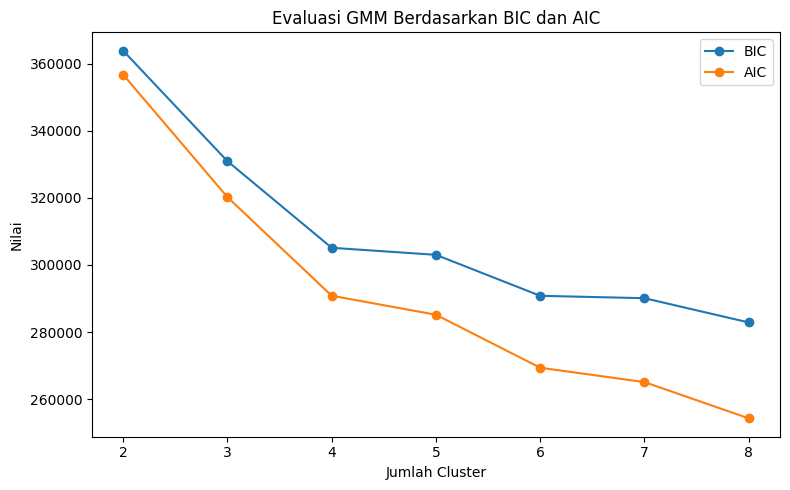

Visualisasi BIC dan AIC GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\gmm_bic_aic_2025.png


In [66]:
# =========================================================
# 6.8 VISUALISASI EVALUASI GMM
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(gmm_metrics["k"], gmm_metrics["bic"], marker="o", label="BIC")
plt.plot(gmm_metrics["k"], gmm_metrics["aic"], marker="o", label="AIC")

plt.title("Evaluasi GMM Berdasarkan BIC dan AIC")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Nilai")
plt.legend()
plt.tight_layout()

gmm_bic_aic_plot_path = FIGURES_DIR / "gmm_bic_aic_2025.png"

plt.savefig(gmm_bic_aic_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi BIC dan AIC GMM disimpan ke:", gmm_bic_aic_plot_path)

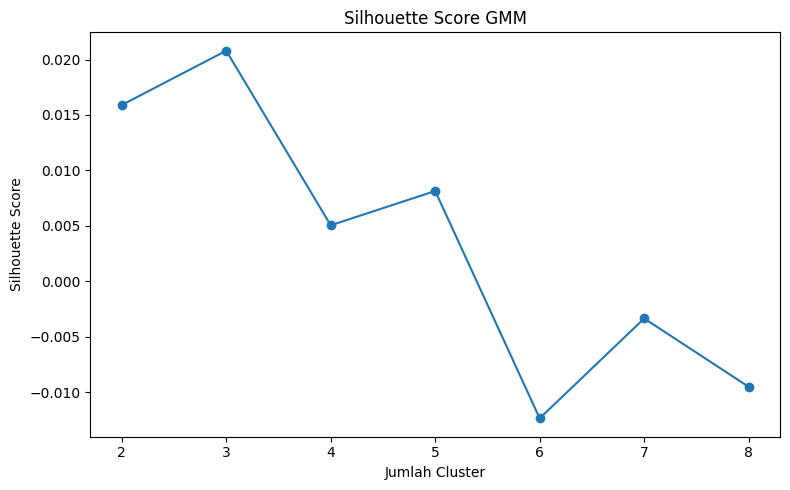

Visualisasi Silhouette Score GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\gmm_silhouette_2025.png


In [67]:
# =========================================================
# 6.9 VISUALISASI SILHOUETTE SCORE GMM
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(gmm_metrics["k"], gmm_metrics["silhouette_score"], marker="o")

plt.title("Silhouette Score GMM")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.tight_layout()

gmm_silhouette_plot_path = FIGURES_DIR / "gmm_silhouette_2025.png"

plt.savefig(gmm_silhouette_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi Silhouette Score GMM disimpan ke:", gmm_silhouette_plot_path)

In [68]:
# =========================================================
# 6.10 SAMPLE PROBABILITAS CLUSTER GMM
# =========================================================

gmm_probability_df = pd.DataFrame(
    gmm_probabilities,
    columns=[f"Cluster_{i}" for i in range(gmm_probabilities.shape[1])]
)

display(gmm_probability_df.head())

gmm_probability_sample_output_path = TABLES_DIR / "gmm_probability_sample_2025.csv"

gmm_probability_df.head(100).to_csv(
    gmm_probability_sample_output_path,
    index=False
)

print("Sample probabilitas cluster GMM disimpan ke:", gmm_probability_sample_output_path)

,Cluster_0,Cluster_1,Cluster_2
0,1.000000e+00,0.000000e+00,4.264985e-31
1,1.000000e+00,0.000000e+00,3.483766e-31
2,2.499830e-46,0.000000e+00,1.000000e+00
3,6.571981e-43,1.800749e-313,1.000000e+00
4,1.055257e-49,0.000000e+00,1.000000e+00


Sample probabilitas cluster GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\gmm_probability_sample_2025.csv


In [69]:
# =========================================================
# 6.11 INTERPRETASI AWAL GMM
# =========================================================

best_gmm_row = gmm_metrics[gmm_metrics["k"] == gmm_best_k]

if not best_gmm_row.empty:
    best_gmm_silhouette = best_gmm_row["silhouette_score"].iloc[0]
    best_gmm_bic = best_gmm_row["bic"].iloc[0]
    best_gmm_aic = best_gmm_row["aic"].iloc[0]

    print("Interpretasi awal GMM")
    print(f"Jumlah cluster terbaik adalah {gmm_best_k}.")
    print(f"Silhouette Score pada cluster terbaik adalah {best_gmm_silhouette:.4f}.")
    print(f"BIC pada cluster terbaik adalah {best_gmm_bic:.2f}.")
    print(f"AIC pada cluster terbaik adalah {best_gmm_aic:.2f}.")

    if best_gmm_silhouette < 0.25:
        print(
            "Nilai Silhouette Score tergolong rendah. "
            "Artinya pemisahan cluster belum terlalu kuat, tetapi GMM tetap berguna karena memberi pendekatan probabilistik terhadap segmentasi developer."
        )
    elif best_gmm_silhouette < 0.50:
        print(
            "Nilai Silhouette Score menunjukkan pemisahan cluster sedang. "
            "GMM dapat digunakan sebagai pembanding terhadap K-Means."
        )
    else:
        print(
            "Nilai Silhouette Score menunjukkan pemisahan cluster yang cukup baik. "
            "GMM dapat digunakan sebagai model segmentasi yang informatif."
        )
else:
    print("Baris gmm_best_k tidak ditemukan pada gmm_metrics.")

Interpretasi awal GMM
Jumlah cluster terbaik adalah 3.
Silhouette Score pada cluster terbaik adalah 0.0208.
BIC pada cluster terbaik adalah 330946.82.
AIC pada cluster terbaik adalah 320225.05.
Nilai Silhouette Score tergolong rendah. Artinya pemisahan cluster belum terlalu kuat, tetapi GMM tetap berguna karena memberi pendekatan probabilistik terhadap segmentasi developer.


## 6.12 GMM Cluster Summary

Bagian ini membuat ringkasan hasil segmentasi Gaussian Mixture Model.

Ringkasan cluster digunakan untuk melihat karakteristik dominan pada setiap cluster GMM, seperti jumlah responden, persentase data, pengalaman coding, negara dominan, tipe developer dominan, pola kerja, dan teknologi yang sering digunakan.

Berbeda dengan K-Means, GMM menggunakan pendekatan probabilistik. Oleh karena itu, bagian ini juga menampilkan rata-rata confidence score, yaitu probabilitas tertinggi yang diberikan GMM untuk cluster terpilih.

In [70]:
# =========================================================
# 6.12 GMM CLUSTER SUMMARY
# =========================================================

print("=" * 60)
print("6.12 GMM CLUSTER SUMMARY")
print("=" * 60)


# =========================================================
# 6.12.1 GENERATE GMM CLUSTER SUMMARY
# =========================================================

gmm_cluster_summary = create_cluster_summary(X, gmm_labels)

display(gmm_cluster_summary)

gmm_cluster_summary_output_path = TABLES_DIR / "gmm_cluster_summary_2025.csv"

gmm_cluster_summary.to_csv(
    gmm_cluster_summary_output_path,
    index=False
)

print("GMM cluster summary disimpan ke:", gmm_cluster_summary_output_path)

6.12 GMM CLUSTER SUMMARY


,Cluster,Jumlah_Data,Persentase,Rata_Rata_YearsCode,Dominan_Age,Dominan_Country,Dominan_EdLevel,Dominan_DevType,Dominan_Employment,Dominan_RemoteWork,Top_LanguageHaveWorkedWith,Top_DatabaseHaveWorkedWith,Top_PlatformHaveWorkedWith,Top_WebframeHaveWorkedWith
0,0,14451,42.86,9.55,25-34 years old,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Employed,Remote,"JavaScript, HTML/CSS, Python, SQL, TypeScript","PostgreSQL, MySQL, SQLite, MongoDB, Redis","Docker, npm, Pip, Amazon Web Services (AWS), Vite","Node.js, React, Next.js, Express, jQuery"
1,1,4753,14.10,16.29,25-34 years old,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Employed,Remote,"Python, C++, C, Bash/Shell (all shells), HTML/CSS","Microsoft SQL Server, Oracle, Microsoft Access...","Splunk, MSBuild, Pacman, Bun, Ninja","ASP.NET, ASP.NET Core, Blazor, Django, Axum"
2,2,14516,43.05,25.06,35-44 years old,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",Employed,Remote,"JavaScript, SQL, HTML/CSS, Python, Bash/Shell ...","PostgreSQL, MySQL, SQLite, Microsoft SQL Serve...","Docker, npm, Amazon Web Services (AWS), Pip, K...","Node.js, React, jQuery, ASP.NET Core, Angular"


GMM cluster summary disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\gmm_cluster_summary_2025.csv


In [71]:
# =========================================================
# 6.12.2 GMM CLUSTER CONFIDENCE SUMMARY
# =========================================================

gmm_confidence_df = pd.DataFrame({
    "Cluster": gmm_labels,
    "Max_Probability": gmm_probabilities.max(axis=1)
})

gmm_confidence_summary = (
    gmm_confidence_df
    .groupby("Cluster")
    .agg(
        Jumlah_Data=("Cluster", "count"),
        Rata_Rata_Confidence=("Max_Probability", "mean"),
        Min_Confidence=("Max_Probability", "min"),
        Max_Confidence=("Max_Probability", "max")
    )
    .reset_index()
)

gmm_confidence_summary["Rata_Rata_Confidence"] = gmm_confidence_summary["Rata_Rata_Confidence"].round(4)
gmm_confidence_summary["Min_Confidence"] = gmm_confidence_summary["Min_Confidence"].round(4)
gmm_confidence_summary["Max_Confidence"] = gmm_confidence_summary["Max_Confidence"].round(4)

display(gmm_confidence_summary)

gmm_confidence_summary_output_path = TABLES_DIR / "gmm_confidence_summary_2025.csv"

gmm_confidence_summary.to_csv(
    gmm_confidence_summary_output_path,
    index=False
)

print("GMM confidence summary disimpan ke:", gmm_confidence_summary_output_path)

,Cluster,Jumlah_Data,Rata_Rata_Confidence,Min_Confidence,Max_Confidence
0,0,14451,0.9964,0.5005,1.0
1,1,4753,0.9977,0.5086,1.0
2,2,14516,0.9963,0.5001,1.0


GMM confidence summary disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\tables\gmm_confidence_summary_2025.csv


## 6.13 Visualisasi Distribusi Cluster GMM

Bagian ini menampilkan distribusi jumlah data pada setiap cluster GMM.

Visualisasi BIC, AIC, dan Silhouette Score sudah dibuat pada bagian sebelumnya. Oleh karena itu, bagian ini hanya fokus pada distribusi cluster.

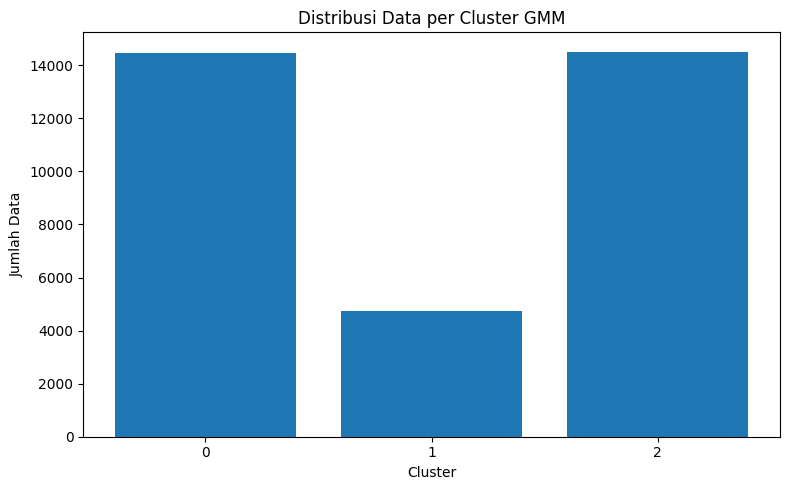

Visualisasi distribusi cluster GMM disimpan ke: c:\Dokumen\Semester 4\Machine Learning\Machine-AI\outputs\figures\gmm_cluster_distribution_2025.png


In [74]:
# =========================================================
# 6.13 VISUALISASI DISTRIBUSI CLUSTER GMM
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    gmm_cluster_distribution["Cluster"].astype(str),
    gmm_cluster_distribution["Jumlah Data"]
)

plt.title("Distribusi Data per Cluster GMM")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.tight_layout()

gmm_cluster_distribution_plot_path = FIGURES_DIR / "gmm_cluster_distribution_2025.png"

plt.savefig(gmm_cluster_distribution_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi distribusi cluster GMM disimpan ke:", gmm_cluster_distribution_plot_path)

## 6.14 Interpretasi Ringkas GMM

Bagian ini menyusun catatan interpretasi hasil segmentasi GMM untuk mendukung penulisan BAB IV.

## 6. Supervised Learning: Random Forest, SVM, XGBoost, MLP

Keempat model dilatih dengan train-test split (random_state=42) dan preprocessing yang sama.


In [75]:
# =========================================================
# 6.14 INTERPRETASI RINGKAS GMM
# =========================================================

print("=" * 60)
print("6.14 INTERPRETASI RINGKAS GMM")
print("=" * 60)

gmm_interpretation_lines = []

gmm_interpretation_lines.append("# Catatan Interpretasi GMM")
gmm_interpretation_lines.append("")
gmm_interpretation_lines.append("Gaussian Mixture Model digunakan sebagai metode soft clustering untuk melakukan segmentasi developer.")
gmm_interpretation_lines.append("GMM berbeda dari K-Means karena setiap data memiliki probabilitas terhadap setiap cluster.")
gmm_interpretation_lines.append("")
gmm_interpretation_lines.append(f"Jumlah cluster terbaik berdasarkan evaluasi adalah {gmm_best_k}.")
gmm_interpretation_lines.append("")

for _, row in gmm_cluster_summary.iterrows():
    cluster_id = row["Cluster"]
    jumlah_data = row["Jumlah_Data"]
    persentase = row["Persentase"]

    confidence_row = gmm_confidence_summary[
        gmm_confidence_summary["Cluster"] == cluster_id
    ]

    gmm_interpretation_lines.append(f"## Cluster {cluster_id}")
    gmm_interpretation_lines.append(f"- Jumlah data: {jumlah_data:,} responden")
    gmm_interpretation_lines.append(f"- Persentase: {persentase}%")

    if not confidence_row.empty:
        avg_confidence = confidence_row["Rata_Rata_Confidence"].iloc[0]
        gmm_interpretation_lines.append(f"- Rata-rata confidence score: {avg_confidence}")

    if "Rata_Rata_YearsCode" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Rata-rata YearsCode: {row['Rata_Rata_YearsCode']} tahun")

    if "Rata_Rata_WorkExp" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Rata-rata WorkExp: {row['Rata_Rata_WorkExp']} tahun")

    if "Dominan_Age" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Kelompok usia dominan: {row['Dominan_Age']}")

    if "Dominan_Country" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Negara dominan: {row['Dominan_Country']}")

    if "Dominan_DevType" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Tipe developer dominan: {row['Dominan_DevType']}")

    if "Dominan_RemoteWork" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Pola kerja dominan: {row['Dominan_RemoteWork']}")

    if "Top_LanguageHaveWorkedWith" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Bahasa pemrograman dominan: {row['Top_LanguageHaveWorkedWith']}")

    if "Top_DatabaseHaveWorkedWith" in gmm_cluster_summary.columns:
        gmm_interpretation_lines.append(f"- Database dominan: {row['Top_DatabaseHaveWorkedWith']}")

    gmm_interpretation_lines.append("")

gmm_interpretation_lines.append("## Kesimpulan Awal")
gmm_interpretation_lines.append(
    "Hasil GMM menunjukkan bahwa segmentasi developer dapat dianalisis secara probabilistik. "
    "Nilai confidence score membantu melihat seberapa kuat setiap data masuk ke cluster tertentu. "
    "Namun, Silhouette Score yang rendah menunjukkan bahwa pemisahan antar cluster belum kuat. "
    "Dengan demikian, GMM digunakan sebagai pembanding terhadap K-Means dan sebagai pendekatan segmentasi yang lebih fleksibel."
)

gmm_interpretation_text = "\n".join(gmm_interpretation_lines)

print(gmm_interpretation_text)

gmm_interpretation_output_path = REPORTS_DIR / "gmm_interpretation_2025.md"

with open(gmm_interpretation_output_path, "w", encoding="utf-8") as file:
    file.write(gmm_interpretation_text)

print("\nCatatan interpretasi GMM disimpan ke:", gmm_interpretation_output_path)

6.14 INTERPRETASI RINGKAS GMM
# Catatan Interpretasi GMM

Gaussian Mixture Model digunakan sebagai metode soft clustering untuk melakukan segmentasi developer.
GMM berbeda dari K-Means karena setiap data memiliki probabilitas terhadap setiap cluster.

Jumlah cluster terbaik berdasarkan evaluasi adalah 3.

## Cluster 0
- Jumlah data: 14,451 responden
- Persentase: 42.86%
- Rata-rata confidence score: 0.9964
- Rata-rata YearsCode: 9.55 tahun
- Kelompok usia dominan: 25-34 years old
- Negara dominan: United States of America
- Tipe developer dominan: Developer, full-stack
- Pola kerja dominan: Remote
- Bahasa pemrograman dominan: JavaScript, HTML/CSS, Python, SQL, TypeScript
- Database dominan: PostgreSQL, MySQL, SQLite, MongoDB, Redis

## Cluster 1
- Jumlah data: 4,753 responden
- Persentase: 14.1%
- Rata-rata confidence score: 0.9977
- Rata-rata YearsCode: 16.29 tahun
- Kelompok usia dominan: 25-34 years old
- Negara dominan: United States of America
- Tipe developer dominan: Developer,

In [ ]:
# =========================================================
# 6. SUPERVISED LEARNING (RF, SVM, XGBOOST, MLP)
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 8: SUPERVISED LEARNING")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN METODE
# ---------------------------------------------------------
print("""
Empat model digunakan untuk klasifikasi AI Usage:

1. Random Forest → ensemble tree-based (robust baseline)
2. Linear SVM → linear classifier baseline
3. XGBoost → gradient boosting (high performance model)
4. MLP Neural Network → deep learning model untuk non-linear pattern

Semua model menggunakan:
- preprocessing yang sama
- stratified train-test split
- random_state = 42 untuk reproducibility
""")


# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------
models, split_data = train_classification_models(
    X,
    y,
    preprocessor,
    test_size=0.2
)


# ---------------------------------------------------------
# INFO DATA SPLIT
# ---------------------------------------------------------
print("\n============= DATA SPLIT =============\n")

print("Ukuran training set:", split_data["X_train"].shape)
print("Ukuran testing set:", split_data["X_test"].shape)


# ---------------------------------------------------------
# MODEL YANG DIGUNAKAN
# ---------------------------------------------------------
print("\n============= MODELS TRAINED =============\n")

for name in models.keys():
    print("-", name)

STEP 8: SUPERVISED LEARNING


Empat model digunakan untuk klasifikasi AI Usage:

1. Random Forest → ensemble tree-based (robust baseline)
2. Linear SVM → linear classifier baseline
3. XGBoost → gradient boosting (high performance model)
4. MLP Neural Network → deep learning model untuk non-linear pattern

Semua model menggunakan:
- preprocessing yang sama
- stratified train-test split
- random_state = 42 untuk reproducibility


============= DATA SPLIT =============

Ukuran training set: (26976, 11)
Ukuran testing set: (6744, 11)

============= MODELS TRAINED =============

- Random Forest
- Linear SVM
- XGBoost
- MLP


## 7. Evaluasi Model Klasifikasi


In [ ]:
# =========================================================
# 7. EVALUASI MODEL KLASIFIKASI
# =========================================================

from IPython.display import display

print("=================================================")
print("STEP 9: MODEL EVALUATION")
print("=================================================\n")


# ---------------------------------------------------------
# PENJELASAN SINGKAT EVALUASI
# ---------------------------------------------------------
print("""
Evaluasi model dilakukan menggunakan beberapa metrik:

- Accuracy → tingkat ketepatan total
- Precision → ketepatan prediksi positif
- Recall → kemampuan menangkap kelas positif
- F1-score → keseimbangan precision & recall

Selain itu:
- Confusion Matrix digunakan untuk melihat kesalahan prediksi
- Classification Report digunakan untuk detail per kelas
""")


# ---------------------------------------------------------
# EVALUASI SEMUA MODEL
# ---------------------------------------------------------
classification_results = evaluate_classification_models(
    models,
    split_data["X_test"],
    split_data["y_test"],
)


# ---------------------------------------------------------
# SIMPAN HASIL EVALUASI
# ---------------------------------------------------------
comparison_df = save_classification_outputs(
    classification_results,
    OUTPUT_ROOT
)


# ---------------------------------------------------------
# VISUALISASI HASIL
# ---------------------------------------------------------
plot_confusion_matrices(classification_results, OUTPUT_ROOT)
plot_model_comparison(comparison_df, OUTPUT_ROOT)


# ---------------------------------------------------------
# TAMPILKAN RINGKASAN MODEL
# ---------------------------------------------------------
print("\n============= MODEL COMPARISON =============\n")
display(comparison_df)


# ---------------------------------------------------------
# DETAIL CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n============= DETAILED REPORT =============\n")

for model_name, result in classification_results.items():

    print("=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    print(result["classification_report_text"])

STEP 9: MODEL EVALUATION


Evaluasi model dilakukan menggunakan beberapa metrik:

- Accuracy → tingkat ketepatan total
- Precision → ketepatan prediksi positif
- Recall → kemampuan menangkap kelas positif
- F1-score → keseimbangan precision & recall

Selain itu:
- Confusion Matrix digunakan untuk melihat kesalahan prediksi
- Classification Report digunakan untuk detail per kelas



NameError: name 'evaluate_classification_models' is not defined

## 8. Visualisasi Performa

In [ ]:
# =========================================================
# 8. VISUALISASI PERFORMA MODEL
# =========================================================

from IPython.display import Image, display
from pathlib import Path

print("=================================================")
print("STEP 10: MODEL PERFORMANCE VISUALIZATION")
print("=================================================\n")


# ---------------------------------------------------------
# 1. PATH GAMBAR
# ---------------------------------------------------------
img_path = FIGURES_DIR / "model_performance_comparison.png"

print("Image path:", img_path)
print("Exists:", img_path.exists())


# ---------------------------------------------------------
# 2. DISPLAY GAMBAR DENGAN SAFETY CHECK
# ---------------------------------------------------------
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("❌ File tidak ditemukan.")
    print("Pastikan plot_model_comparison sudah dijalankan di cell sebelumnya.")

STEP 10: MODEL PERFORMANCE VISUALIZATION



NameError: name 'FIGURES_DIR' is not defined

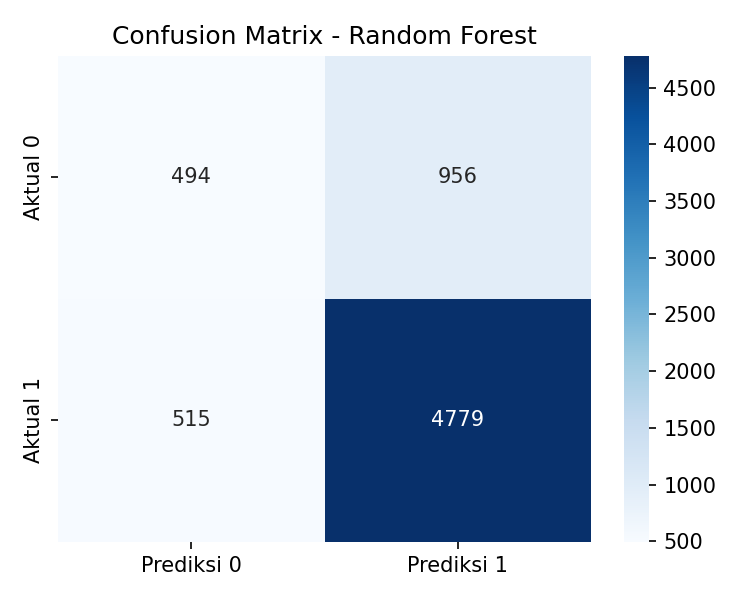

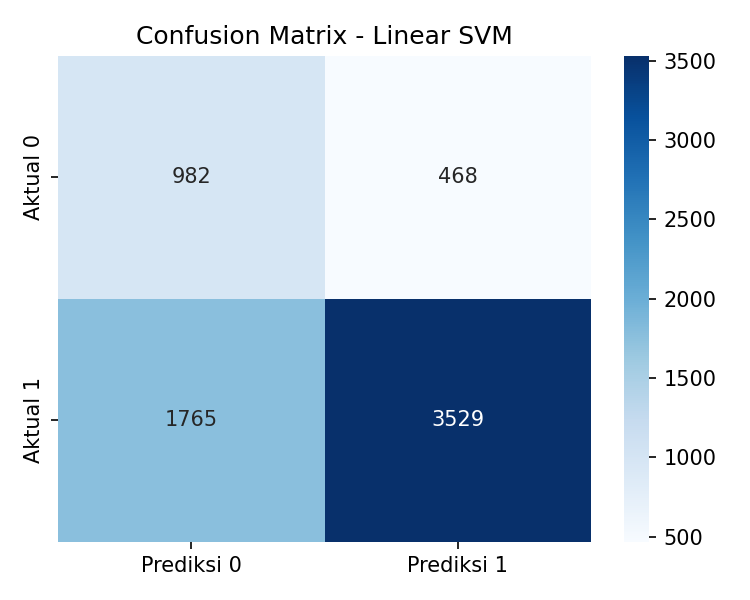

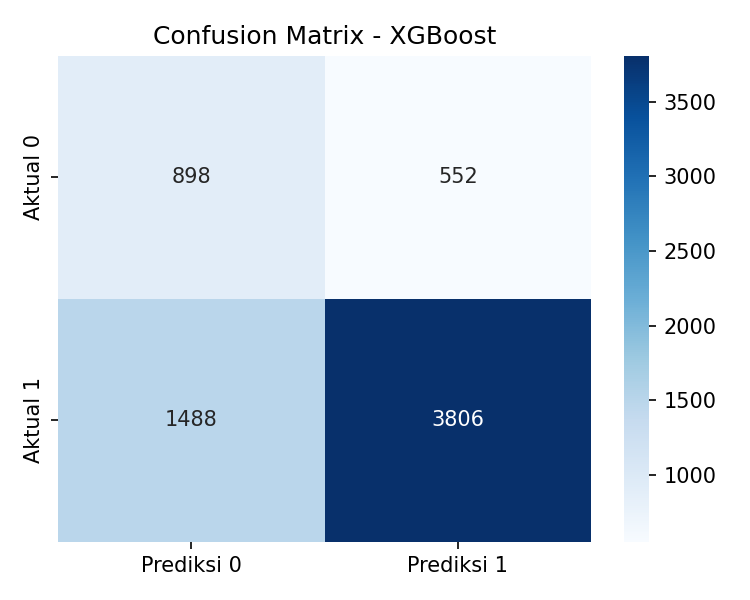

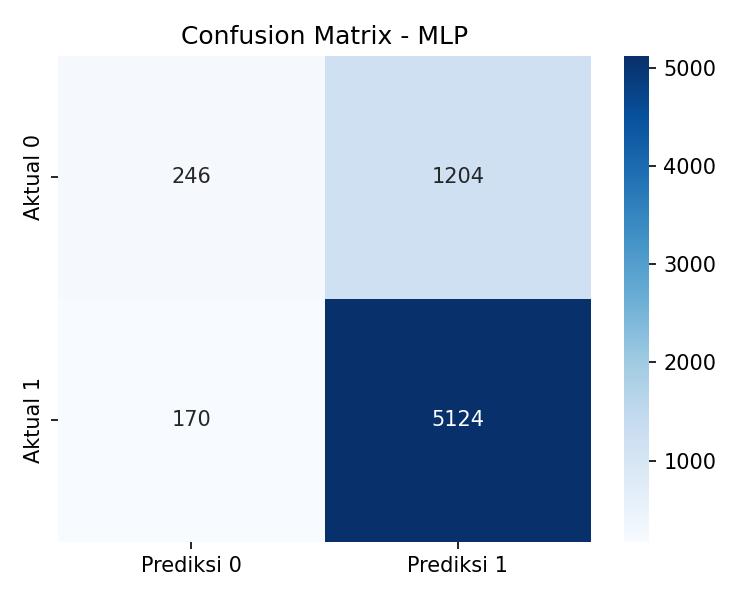

In [ ]:
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_random_forest.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_linear_svm.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_xgboost.png')))
display(Img(filename=str(FIGURES_DIR / 'confusion_matrix_mlp.png')))


## 8. Ringkasan untuk BAB IV


In [ ]:
best_model_row = comparison_df.sort_values("f1_score", ascending=False).iloc[0]

summary_text = f"""# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: {df.shape[0]:,}.
- Jumlah kolom awal: {df.shape[1]:,}.
- Jumlah data setelah target kosong dibuang: {metadata['n_rows_after_target_drop']:,}.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: {metadata['target_source_col']}.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {metadata['target_distribution']}.

## Fitur
- Fitur digunakan: {', '.join(metadata['available_features'])}.
- Fitur kandidat yang tidak tersedia: {', '.join(metadata['missing_features']) if metadata['missing_features'] else '-'}.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diubah menjadi token biner.
- Fitur numerik di-scaling dengan StandardScaler.

## K-Means Clustering
- Rentang k diuji: 2 sampai 10.
- Nilai k terpilih berdasarkan silhouette score tertinggi: {best_k}.
- Tabel interpretasi cluster tersimpan di outputs/tables/cluster_summary.csv.
- Grafik elbow dan silhouette tersimpan di outputs/figures/kmeans_elbow_silhouette.png.

## Evaluasi Model Klasifikasi
- Model terbaik berdasarkan F1-score: {best_model_row['model']}.
- Accuracy: {best_model_row['accuracy']:.4f}.
- Precision: {best_model_row['precision']:.4f}.
- Recall: {best_model_row['recall']:.4f}.
- F1-score: {best_model_row['f1_score']:.4f}.
- Tabel perbandingan model tersimpan di outputs/tables/model_performance_comparison.csv.
"""

report_path = REPORTS_DIR / "bab_iv_ringkasan_awal.md"
report_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print(f"Ringkasan disimpan ke: {report_path}")

# Ringkasan Awal BAB IV

## Deskripsi Dataset
- Dataset: Stack Overflow Developer Survey 2025.
- Jumlah baris awal: 49,191.
- Jumlah kolom awal: 172.
- Jumlah data setelah target kosong dibuang: 33,720.

## Target Prediksi
- Target: AI_Usage.
- Sumber target: AISelect.
- Mapping: 1 = menggunakan AI tools, 0 = tidak menggunakan AI tools.
- Distribusi target: {0: 7251, 1: 26469}.

## Fitur
- Fitur digunakan: Age, Country, EdLevel, DevType, Employment, RemoteWork, YearsCode, LanguageHaveWorkedWith, DatabaseHaveWorkedWith, PlatformHaveWorkedWith, WebframeHaveWorkedWith.
- Fitur kandidat yang tidak tersedia: YearsCodePro, ToolsTechHaveWorkedWith.
- Kolom AI tidak dipakai sebagai input untuk menghindari data leakage.

## Preprocessing
- Missing value numerik diisi median.
- Missing value kategorikal diisi Unknown.
- YearsCode/YearsCodePro dikonversi ke numerik jika tersedia.
- Fitur kategorikal di-encode dengan One-Hot Encoding.
- Fitur multi-select dipisahkan berdasarkan titik koma dan diub